<a href="https://colab.research.google.com/github/DevKnight4/ml-algorithm-implementations/blob/main/neural-networks/backprop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BACK PROPAGATION IMPLEMENTATION**

In [10]:
import numpy as np

In [11]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# Step1: Build Architecture

In [12]:
INPUT_SIZE = 2
HIDDEN_SIZE = 4
OUTPUT_SIZE = 1

In [23]:
np.random.seed(77)

In [13]:
weights_input_hidden = np.random.randn(INPUT_SIZE, HIDDEN_SIZE) * 0.5
bias_hidden = np.zeros((1, HIDDEN_SIZE))

In [14]:
weights_hidden_output = np.random.randn(HIDDEN_SIZE, OUTPUT_SIZE) * 0.5
bias_output = np.zeros((1, OUTPUT_SIZE))

In [15]:
print("Network initialized with random weights:")
print(f"  Input → Hidden weights shape: {weights_input_hidden.shape}")
print(f"  Hidden → Output weights shape: {weights_hidden_output.shape}")
print(f"\nTotal parameters: {weights_input_hidden.size + bias_hidden.size + weights_hidden_output.size + bias_output.size}")

Network initialized with random weights:
  Input → Hidden weights shape: (2, 4)
  Hidden → Output weights shape: (4, 1)

Total parameters: 17


# Step2: Activation Function

**Sigmoid Function**

In [16]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

In [17]:
def sigmoid_derivative(x):
  s = sigmoid(x)
  return s * (1 - s)

# Step3: Forward Pass

**Linear Combination -> Activation Function**

In [18]:
def forward(x):

  z_hidden = np.dot(x, weights_input_hidden) + bias_hidden

  a_hidden = sigmoid(z_hidden)

  z_output = np.dot(a_hidden, weights_hidden_output) + bias_output

  a_output = sigmoid(z_output)

  return z_hidden, a_hidden, z_output, a_output

In [19]:
z_h, a_h, z_o, predictions = forward(X)
print("Forward pass with UNTRAINED network:")
print("-" * 50)
for i in range(len(X)):
    print(f"Input: {X[i]} → Prediction: {predictions[i][0]:.4f} (Target: {y[i][0]})")

print("\n❌ Predictions are garbage — the network hasn't learned anything yet.")

Forward pass with UNTRAINED network:
--------------------------------------------------
Input: [0 0] → Prediction: 0.7010 (Target: 0)
Input: [0 1] → Prediction: 0.6996 (Target: 1)
Input: [1 0] → Prediction: 0.7152 (Target: 1)
Input: [1 1] → Prediction: 0.7135 (Target: 0)

❌ Predictions are garbage — the network hasn't learned anything yet.


# Step4: Loss Function

**Mean Squared Error**

In [20]:
def compute_loss(y_true, y_pred):
  return np.mean(np.square(y_true - y_pred))

In [21]:
initial_loss = compute_loss(y, predictions)
print(f"Initial Loss (untrained): {initial_loss:.4f}")
print("\nThis number should decrease as we train.")

Initial Loss (untrained): 0.2930

This number should decrease as we train.


# Step5: Back Propagation

In [22]:
def backward(X, y, z_hidden, a_hidden, z_output, a_output, learning_rate):
  global weights_input_hidden, bias_hidden, weights_hidden_output, bias_output

  m = X.shape[0]

  #==============OUTPUT LAYER================#
  output_error = a_output - y
  output_delta = output_error * sigmoid_derivative(z_output)

  grad_weights_hidden_output = np.dot(a_hidden.T, output_delta) / m
  grad_bias_output = np.mean(output_delta, axis=0, keepdims=True)

  #===============HIDDEN LAYER================#
  hidden_error = np.dot(output_delta, weights_hidden_output.T)
  hidden_delta = hidden_error * sigmoid_derivative(z_hidden)

  grad_weights_input_hidden = np.dot(X.T, hidden_delta) / m
  grad_bias_hidden = np.mean(hidden_delta, axis=0, keepdims=True)

  #==============UPDATE WEIGHTS==============#
  weights_hidden_output -= learning_rate * grad_weights_hidden_output
  bias_output -= learning_rate * grad_bias_output
  weights_input_hidden -= learning_rate * grad_weights_input_hidden
  bias_hidden -= learning_rate * grad_bias_hidden

print("Backpropagation function defined.")

Backpropagation function defined.


# Step6: Training Loop

In [24]:
learning_rate = 2.0
iterations = 10000

In [25]:
loss_history = []

In [26]:
print("Training started...")
print("-" * 50)

for i in range(iterations):
  z_h, a_h, z_o, pred = forward(X)

  loss = compute_loss(y, pred)
  loss_history.append(loss)

  backward(X, y, z_h, a_h, z_o, pred, learning_rate)

  if(i % 2000 == 0):
      print(f"Iteration {i:5d} | Loss: {loss:.6f}")

Training started...
--------------------------------------------------
Iteration     0 | Loss: 0.292963
Iteration  2000 | Loss: 0.007157
Iteration  4000 | Loss: 0.000923
Iteration  6000 | Loss: 0.000453
Iteration  8000 | Loss: 0.000294


In [27]:
# Final predictions
_, _, _, final_predictions = forward(X)

print("Final Results After Training:")
print("-" * 50)
print(f"{'Input':<12} {'Target':<10} {'Prediction':<12} {'Rounded':<10}")
print("-" * 50)

for i in range(len(X)):
    pred = final_predictions[i][0]
    rounded = round(pred)
    status = "✅" if rounded == y[i][0] else "❌"
    print(f"{str(X[i]):<12} {y[i][0]:<10} {pred:<12.4f} {rounded:<10} {status}")

print("-" * 50)
print(f"\n🎉 The network learned XOR from random weights!")

Final Results After Training:
--------------------------------------------------
Input        Target     Prediction   Rounded   
--------------------------------------------------
[0 0]        0          0.0150       0          ✅
[0 1]        1          0.9882       1          ✅
[1 0]        1          0.9843       1          ✅
[1 1]        0          0.0160       0          ✅
--------------------------------------------------

🎉 The network learned XOR from random weights!


In [28]:
import matplotlib.pyplot as plt

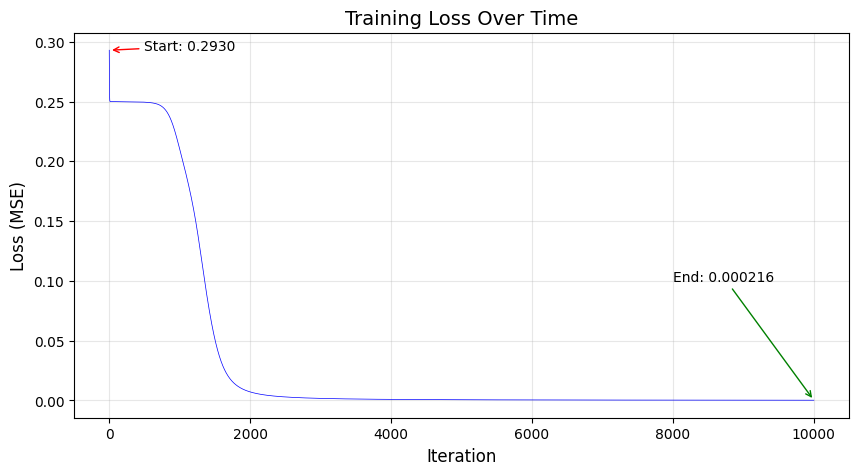

The loss started high (random guessing) and decreased (learning).


In [29]:
# Plot the loss curve
plt.figure(figsize=(10, 5))
plt.plot(loss_history, 'b-', linewidth=0.5)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training Loss Over Time', fontsize=14)
plt.grid(True, alpha=0.3)

# Add annotations
plt.annotate(f'Start: {loss_history[0]:.4f}',
             xy=(0, loss_history[0]), fontsize=10,
             xytext=(500, loss_history[0]),
             arrowprops=dict(arrowstyle='->', color='red'))
plt.annotate(f'End: {loss_history[-1]:.6f}',
             xy=(len(loss_history)-1, loss_history[-1]), fontsize=10,
             xytext=(len(loss_history)-2000, 0.1),
             arrowprops=dict(arrowstyle='->', color='green'))

plt.show()

print("The loss started high (random guessing) and decreased (learning).")